# Rich analysis — calibration, selective prediction, ROC

Reads per-model data in `conf12_*.npz` (regenerate with `run12.py`) and builds the figures that turn AUROC numbers into meaning:
1. **Cross-model AUROC** — verbalized vs token vs probe across all models.
2. **Calibration / reliability** — when a signal says 90% sure, is it right 90% of the time? (+ ECE)
3. **Selective prediction / risk-coverage** — let the model abstain on its least-confident answers and watch accuracy climb.
4. **ROC + score distributions** — how separable correct vs wrong is.

The probe uses the **best layer per model (5-fold CV)**. Note: best-layer selection is mildly optimistic — nested CV deflates it ~0.05 (see notebook 04). The answer-token-probability signal needs no layer selection, so treat it as the robust internal baseline.

In [1]:
import numpy as np, glob, os
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
cv=StratifiedKFold(5,shuffle=True,random_state=0)
pipe=lambda: make_pipeline(StandardScaler(),LogisticRegression(C=0.05,max_iter=3000))
def load(short):
    d=np.load(f"conf12_{short}.npz"); X,y,ct,cvb=d["X"],d["y"],d["conf_tok"],d["conf_verb"]
    aucs=[roc_auc_score(y,cross_val_predict(pipe(),X[:,L,:],y,cv=cv,method="predict_proba")[:,1]) for L in range(X.shape[1])]
    bL=int(np.argmax(aucs)); probe_p=cross_val_predict(pipe(),X[:,bL,:],y,cv=cv,method="predict_proba")[:,1]
    return dict(short=short,y=y,verbal=cvb,token=ct,probe=probe_p,layer=bL,acc=float(y.mean()),
                auc_v=roc_auc_score(y,cvb),auc_t=roc_auc_score(y,ct),auc_p=max(aucs))
shorts=sorted(os.path.basename(f)[7:-4] for f in glob.glob("conf12_*.npz"))
DATA={s:load(s) for s in shorts}
print(f"{'model':16s}{'acc':>6s}{'verbal':>8s}{'token':>7s}{'probe':>7s}")
for s,m in DATA.items(): print(f"{s:16s}{m['acc']:6.0%}{m['auc_v']:8.3f}{m['auc_t']:7.3f}{m['auc_p']:7.3f}")

model              acc  verbal  token  probe
Falcon3-1B         71%   0.572  0.615  0.816
Gemma-2-2B         96%   0.551  0.673  0.810
Granite-3.1-2B     89%   0.497  0.841  0.733
Llama-3.2-1B       68%   0.508  0.812  0.803
Llama-3.2-3B       96%   0.486  0.804  0.662
OLMo-2-1B          66%   0.500  0.827  0.745
Phi-3.5-mini       96%   0.497  0.876  0.787
Qwen2.5-0.5B       36%   0.646  0.620  0.815
Qwen2.5-1.5B       92%   0.571  0.852  0.785
SmolLM2-1.7B       43%   0.317  0.851  0.870
SmolLM2-360M       70%   0.632  0.605  0.663
StableLM-2-1.6B    51%   0.748  0.836  0.845


## 1. Cross-model AUROC

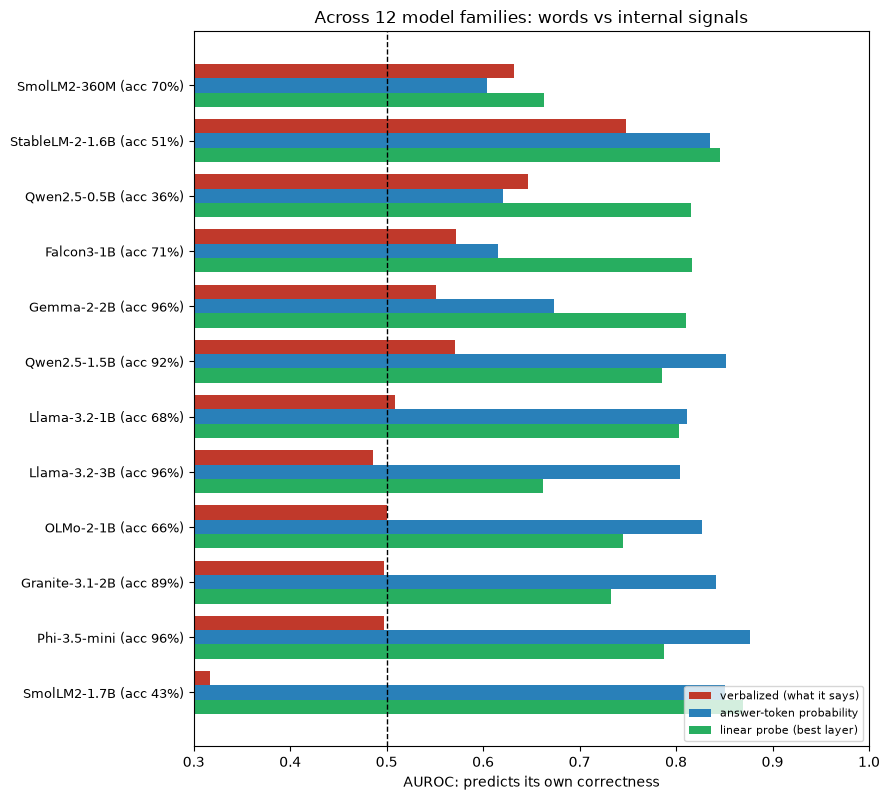

In [2]:
rows=sorted(DATA.values(), key=lambda m: max(m['auc_t'],m['auc_p'])-m['auc_v'], reverse=True)
ys=np.arange(len(rows)); h=0.26
fig,ax=plt.subplots(figsize=(9,0.55*len(rows)+1.5))
ax.barh(ys+h,[m['auc_v'] for m in rows],h,color="#c0392b",label="verbalized (what it says)")
ax.barh(ys,[m['auc_t'] for m in rows],h,color="#2980b9",label="answer-token probability")
ax.barh(ys-h,[m['auc_p'] for m in rows],h,color="#27ae60",label="linear probe (best layer)")
ax.axvline(0.5,color="k",ls="--",lw=1); ax.set_xlim(0.3,1.0)
ax.set_yticks(ys); ax.set_yticklabels([f"{m['short']} (acc {m['acc']:.0%})" for m in rows],fontsize=9)
ax.set_xlabel("AUROC: predicts its own correctness"); ax.legend(loc="lower right",fontsize=8)
ax.set_title("Across 12 model families: words vs internal signals"); plt.tight_layout(); plt.savefig("fig_crossmodel.png",dpi=130); plt.show()

## 2. Calibration / reliability diagram (+ ECE)

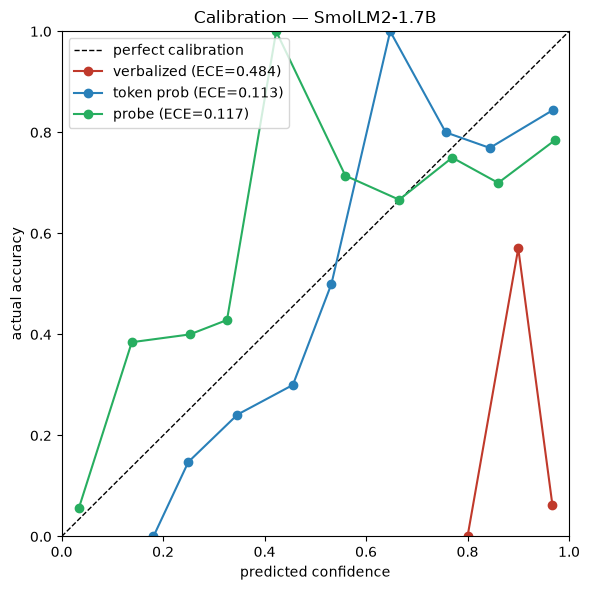

In [3]:
MODEL="SmolLM2-1.7B"   # change to any loaded model
m=DATA[MODEL]
def ece(conf,corr,bins=10):
    edges=np.linspace(0,1,bins+1); e=0
    for i in range(bins):
        sel=(conf>edges[i])&(conf<=edges[i+1])
        if sel.sum(): e+=abs(corr[sel].mean()-conf[sel].mean())*sel.sum()/len(conf)
    return e
def reliability(conf,corr,bins=10):
    edges=np.linspace(0,1,bins+1); xs=[];ac=[]
    for i in range(bins):
        sel=(conf>edges[i])&(conf<=edges[i+1])
        if sel.sum(): xs.append(conf[sel].mean()); ac.append(corr[sel].mean())
    return np.array(xs),np.array(ac)
fig,ax=plt.subplots(figsize=(6,6)); ax.plot([0,1],[0,1],"k--",lw=1,label="perfect calibration")
for name,key,c in [("verbalized","verbal","#c0392b"),("token prob","token","#2980b9"),("probe","probe","#27ae60")]:
    xs,ac=reliability(m[key],m["y"]); ax.plot(xs,ac,"-o",color=c,label=f"{name} (ECE={ece(m[key],m['y']):.3f})")
ax.set_xlabel("predicted confidence"); ax.set_ylabel("actual accuracy"); ax.set_title(f"Calibration — {MODEL}")
ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1); plt.tight_layout(); plt.savefig("fig_calibration.png",dpi=130); plt.show()

## 3. Selective prediction / risk-coverage — "predict with a model" 

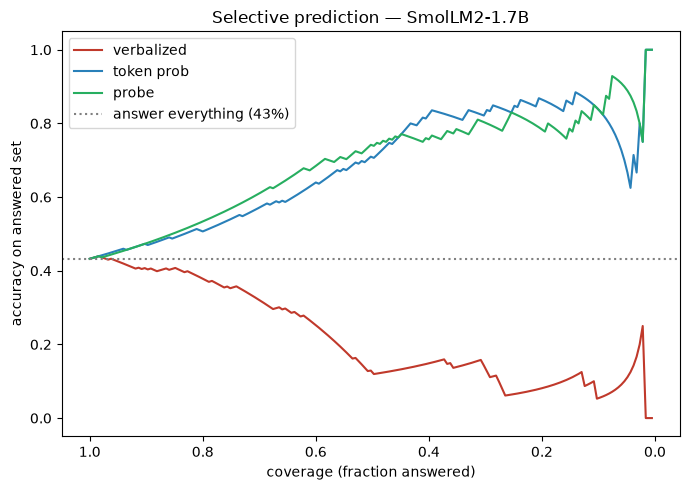

answer only the most-confident X% (by probe):
  coverage 100%: accuracy 43.2%
  coverage 80%: accuracy 53.4%
  coverage 60%: accuracy 68.5%
  coverage 40%: accuracy 75.7%


In [4]:
def risk_coverage(score,corr):
    order=np.argsort(-score); ys2=corr[order]
    return np.arange(1,len(ys2)+1)/len(ys2), np.cumsum(ys2)/np.arange(1,len(ys2)+1)
fig,ax=plt.subplots(figsize=(7,5))
for name,key,c in [("verbalized","verbal","#c0392b"),("token prob","token","#2980b9"),("probe","probe","#27ae60")]:
    cov,acc=risk_coverage(m[key],m["y"]); ax.plot(cov,acc,color=c,label=name)
ax.axhline(m["acc"],color="gray",ls=":",label=f"answer everything ({m['acc']:.0%})")
ax.set_xlabel("coverage (fraction answered)"); ax.set_ylabel("accuracy on answered set")
ax.set_title(f"Selective prediction — {MODEL}"); ax.legend(); ax.invert_xaxis()
plt.tight_layout(); plt.savefig("fig_risk_coverage.png",dpi=130); plt.show()
cov,acc=risk_coverage(m["probe"],m["y"])
print("answer only the most-confident X% (by probe):")
for c in [1.0,0.8,0.6,0.4]:
    i=min(len(cov)-1,int(c*len(cov))-1); print(f"  coverage {c:.0%}: accuracy {acc[i]:.1%}")

## 4. ROC + score distributions

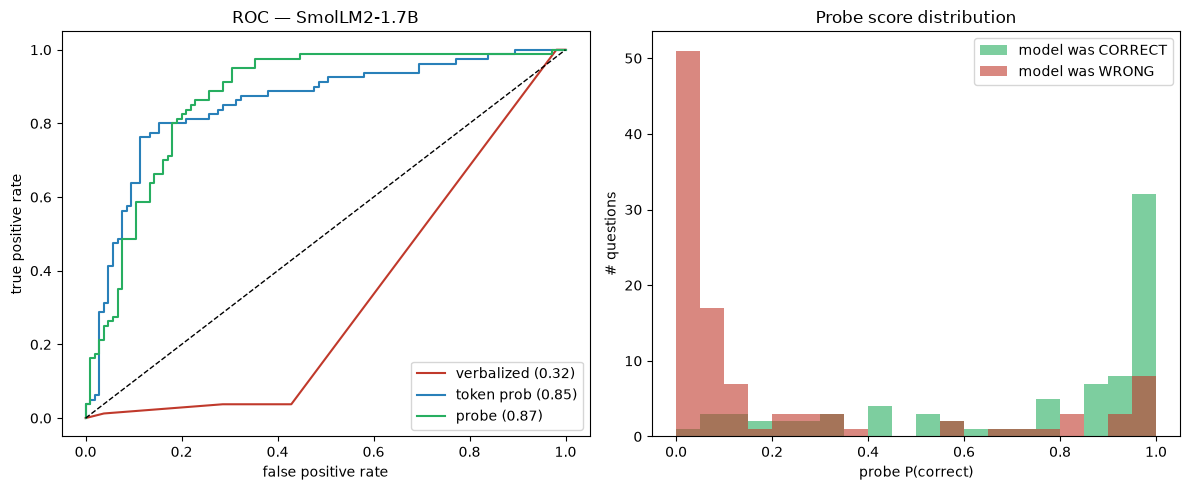

In [5]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,5))
for name,key,c in [("verbalized","verbal","#c0392b"),("token prob","token","#2980b9"),("probe","probe","#27ae60")]:
    fpr,tpr,_=roc_curve(m["y"],m[key]); a1.plot(fpr,tpr,color=c,label=f"{name} ({roc_auc_score(m['y'],m[key]):.2f})")
a1.plot([0,1],[0,1],"k--",lw=1); a1.set_xlabel("false positive rate"); a1.set_ylabel("true positive rate"); a1.set_title(f"ROC — {MODEL}"); a1.legend()
bins=np.linspace(0,1,21)
a2.hist(m["probe"][m["y"]==1],bins=bins,alpha=.6,color="#27ae60",label="model was CORRECT")
a2.hist(m["probe"][m["y"]==0],bins=bins,alpha=.6,color="#c0392b",label="model was WRONG")
a2.set_xlabel("probe P(correct)"); a2.set_ylabel("# questions"); a2.set_title("Probe score distribution"); a2.legend()
plt.tight_layout(); plt.savefig("fig_roc_dist.png",dpi=130); plt.show()